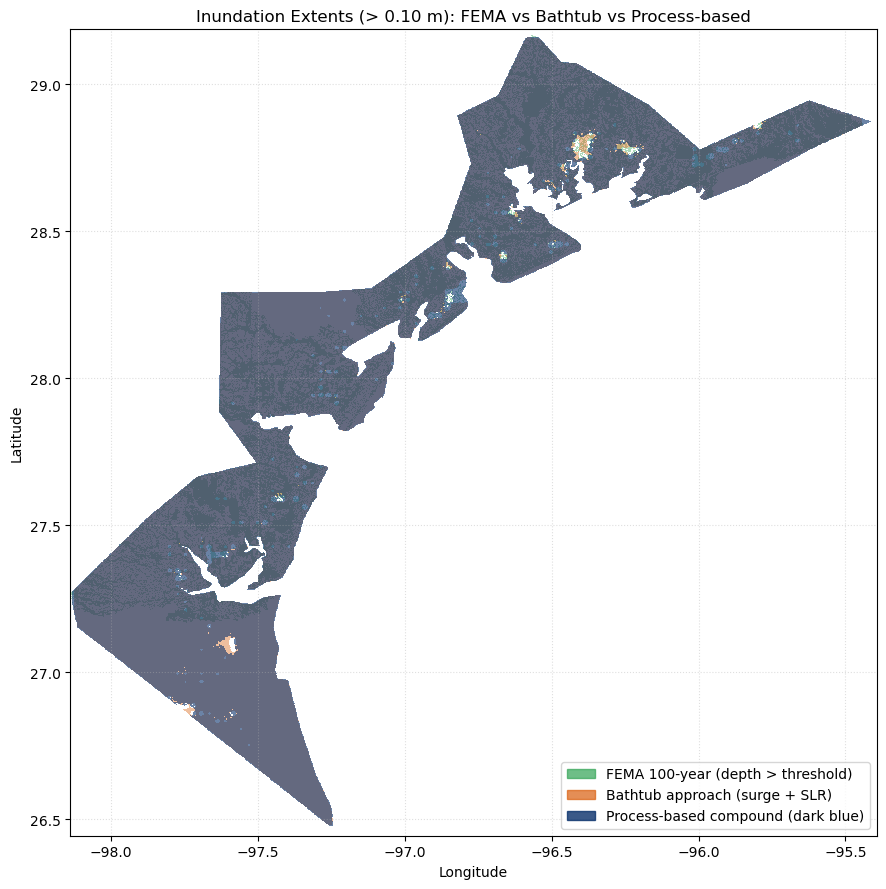

In [1]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math

# ---------- USER INPUTS ----------
THRESHOLD = 0.10  # meters; pixel is inundated if depth > THRESHOLD

r_fema     = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Common plotting CRS (lat/lon) and resolution (degrees per pixel)
TARGET_CRS = "EPSG:4326"
TARGET_RES_DEG = 0.0005  # ~55 m at equator; ~45–50 m near TX; increase if memory is an issue
# ----------------------------------

def read_wet_mask(path, threshold=THRESHOLD):
    """Read a depth raster and return (mask_bool, profile_dict). mask_true = depth > threshold."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)  # MaskedArray using src.nodata if set
        # Build wet mask: valid & finite & > threshold
        valid = (~arr.mask) & np.isfinite(arr)
        wet = np.zeros(arr.shape, dtype="uint8")
        wet[valid & (arr > threshold)] = 1
        prof = {
            "crs": src.crs,
            "transform": src.transform,
            "width": src.width,
            "height": src.height
        }
    return wet, prof

def union_bounds_in_target(profiles, target_crs=TARGET_CRS):
    """Compute union of the input rasters' bounds in target CRS."""
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        tb = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(tb[0]); ys_min.append(tb[1]); xs_max.append(tb[2]); ys_max.append(tb[3])
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res_deg=TARGET_RES_DEG):
    """Build a destination transform/shape for imshow in target CRS."""
    width  = int(math.ceil((right  - left) / res_deg))
    height = int(math.ceil((top    - bottom) / res_deg))
    transform = from_origin(left, top, res_deg, res_deg)
    return transform, width, height

def reproject_mask_bool(src_mask_uint8, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    """Reproject a 0/1 uint8 mask to the common grid (nearest)."""
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask_uint8,
        destination=dst,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
    return dst

# --- 1) Read wet masks for all three rasters ---
wet_fema,     prof_fema     = read_wet_mask(r_fema)
wet_bathtub,  prof_bathtub  = read_wet_mask(r_bathtub)
wet_compound, prof_compound = read_wet_mask(r_compound)

# --- 2) Build a common grid in EPSG:4326 covering all datasets ---
left, bottom, right, top = union_bounds_in_target(
    [prof_fema, prof_bathtub, prof_compound], target_crs=TARGET_CRS
)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES_DEG)

# --- 3) Reproject masks to the common grid ---
dst_fema = reproject_mask_bool(wet_fema, prof_fema, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_bath = reproject_mask_bool(wet_bathtub, prof_bathtub, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_comp = reproject_mask_bool(wet_compound, prof_compound, dst_transform, TARGET_CRS, dst_w, dst_h)

# --- 4) Plot with transparent overlays ---
fig, ax = plt.subplots(figsize=(10, 9))

# Build colormaps: 0 -> fully transparent; 1 -> colored (with alpha)
cmap_compound = ListedColormap([(0, 0, 0, 0), (8/255, 48/255, 107/255, 0.60)])  # dark blue, 60% alpha
cmap_bathtub  = ListedColormap([(0, 0, 0, 0), (217/255, 95/255, 14/255, 0.40)])  # orange, 40% alpha
cmap_fema     = ListedColormap([(0, 0, 0, 0), (49/255, 163/255, 84/255, 0.40)])  # green, 40% alpha

extent = (left, right, bottom, top)

# Plot order: FEMA first, then Bathtub, then Compound on top
ax.imshow(dst_fema, extent=extent, origin="upper", cmap=cmap_fema, interpolation="nearest")
ax.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bathtub, interpolation="nearest")
ax.imshow(dst_comp, extent=extent, origin="upper", cmap=cmap_compound, interpolation="nearest")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Inundation Extents (> {THRESHOLD:.2f} m): FEMA vs Bathtub vs Process-based")

# Make a clean legend with colored patches
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=(49/255, 163/255, 84/255, 0.70), label="FEMA 100-year (depth > threshold)"),
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.70), label="Bathtub approach (surge + SLR)"),
    mpatches.Patch(color=(8/255, 48/255, 107/255, 0.80), label="Process-based compound (dark blue)"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=True)

ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()


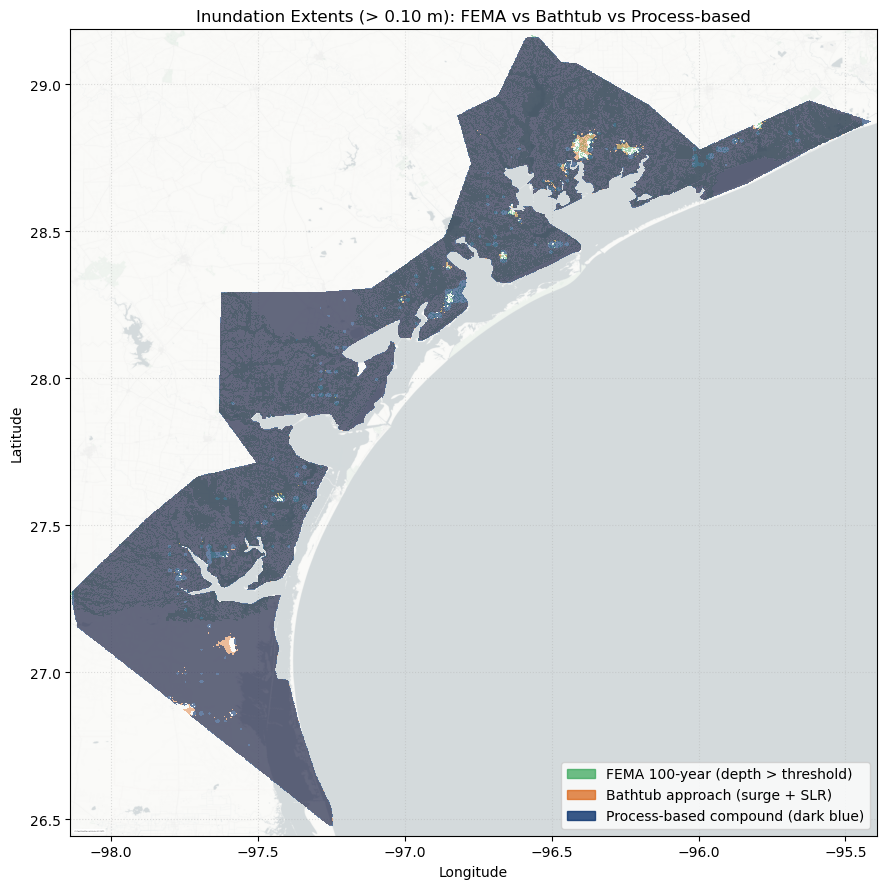

In [2]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import contextily as ctx  # <- NEW

# ---------- USER INPUTS ----------
THRESHOLD = 0.10  # meters; pixel is inundated if depth > THRESHOLD

r_fema     = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Common plotting CRS (lat/lon) and resolution (degrees per pixel)
TARGET_CRS = "EPSG:4326"
TARGET_RES_DEG = 0.0005  # ~55 m at equator; ~45–50 m near TX; increase if memory is an issue
# ----------------------------------

def read_wet_mask(path, threshold=THRESHOLD):
    """Read a depth raster and return (mask_bool, profile_dict). mask_true = depth > threshold."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)  # MaskedArray using src.nodata if set
        # Build wet mask: valid & finite & > threshold
        valid = (~arr.mask) & np.isfinite(arr)
        wet = np.zeros(arr.shape, dtype="uint8")
        wet[valid & (arr > threshold)] = 1
        prof = {
            "crs": src.crs,
            "transform": src.transform,
            "width": src.width,
            "height": src.height
        }
    return wet, prof

def union_bounds_in_target(profiles, target_crs=TARGET_CRS):
    """Compute union of the input rasters' bounds in target CRS."""
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        tb = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(tb[0]); ys_min.append(tb[1]); xs_max.append(tb[2]); ys_max.append(tb[3])
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res_deg=TARGET_RES_DEG):
    """Build a destination transform/shape for imshow in target CRS."""
    width  = int(math.ceil((right  - left) / res_deg))
    height = int(math.ceil((top    - bottom) / res_deg))
    transform = from_origin(left, top, res_deg, res_deg)
    return transform, width, height

def reproject_mask_bool(src_mask_uint8, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    """Reproject a 0/1 uint8 mask to the common grid (nearest)."""
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask_uint8,
        destination=dst,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
    return dst

# --- 1) Read wet masks for all three rasters ---
wet_fema,     prof_fema     = read_wet_mask(r_fema)
wet_bathtub,  prof_bathtub  = read_wet_mask(r_bathtub)
wet_compound, prof_compound = read_wet_mask(r_compound)

# --- 2) Build a common grid in EPSG:4326 covering all datasets ---
left, bottom, right, top = union_bounds_in_target(
    [prof_fema, prof_bathtub, prof_compound], target_crs=TARGET_CRS
)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES_DEG)

# --- 3) Reproject masks to the common grid ---
dst_fema = reproject_mask_bool(wet_fema, prof_fema, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_bath = reproject_mask_bool(wet_bathtub, prof_bathtub, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_comp = reproject_mask_bool(wet_compound, prof_compound, dst_transform, TARGET_CRS, dst_w, dst_h)

# --- 4) Plot with transparent overlays + BASEMAP ---
fig, ax = plt.subplots(figsize=(10, 9))

# Build colormaps: 0 -> fully transparent; 1 -> colored (with alpha)
cmap_compound = ListedColormap([(0, 0, 0, 0), (8/255, 48/255, 107/255, 0.60)])  # dark blue, 60% alpha
cmap_bathtub  = ListedColormap([(0, 0, 0, 0), (217/255, 95/255, 14/255, 0.40)]) # orange, 40% alpha
cmap_fema     = ListedColormap([(0, 0, 0, 0), (49/255, 163/255, 84/255, 0.40)]) # green, 40% alpha

extent = (left, right, bottom, top)

# Plot order: FEMA first, then Bathtub, then Compound on top
ax.imshow(dst_fema, extent=extent, origin="upper", cmap=cmap_fema, interpolation="nearest", zorder=3)
ax.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bathtub, interpolation="nearest", zorder=4)
ax.imshow(dst_comp, extent=extent, origin="upper", cmap=cmap_compound, interpolation="nearest", zorder=5)

# 3) Add basemap underneath
crs = TARGET_CRS  # axis is in EPSG:4326
ctx.add_basemap(
    ax,
    crs=crs,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=12,
    zorder=1,          # tiles at the bottom
    attribution_size=0
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Inundation Extents (> {THRESHOLD:.2f} m): FEMA vs Bathtub vs Process-based")

# Legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=(49/255, 163/255, 84/255, 0.70), label="FEMA 100-year (depth > threshold)"),
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.70), label="Bathtub approach (surge + SLR)"),
    mpatches.Patch(color=(8/255, 48/255, 107/255, 0.80), label="Process-based compound (dark blue)"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=True)

ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()


C:\Users\sahad2\AppData\Local\Temp\ipykernel_29216\441343547.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


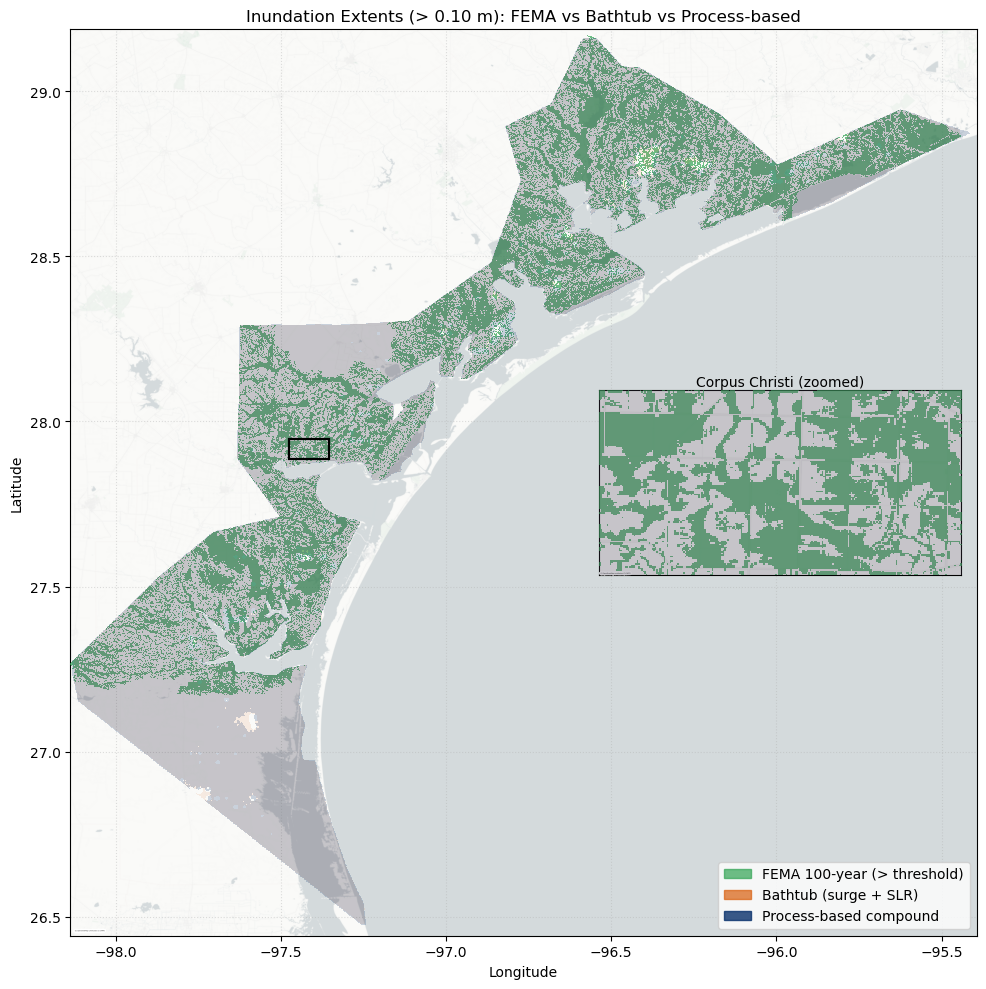

In [9]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import contextily as ctx
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# ---------- USER INPUTS ----------
THRESHOLD = 0.10  # meters; pixel is inundated if depth > THRESHOLD

r_fema     = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Common plotting CRS (lat/lon) and resolution (degrees per pixel)
TARGET_CRS = "EPSG:4326"
TARGET_RES_DEG = 0.0005  # ~45–55 m; increase if memory is an issue

# Inset window (Corpus Christi area) in lon/lat [left, bottom, right, top]
INSET_BBOX = (-97.475853,27.886425,-97.355347,27.947706)   # adjust if needed
INSET_SIZE = ("40%", "40%")                   # inset size relative to the main ax
INSET_LOC  = "center right"                     # where the inset sits on the main fig
INSET_ZOOM = 13                               # basemap zoom for inset
MAIN_ZOOM  = 12                               # basemap zoom for main map
# ----------------------------------

def read_wet_mask(path, threshold=THRESHOLD):
    """Read a depth raster and return (mask_bool, profile_dict). mask_true = depth > threshold."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)
        valid = (~arr.mask) & np.isfinite(arr)
        wet = np.zeros(arr.shape, dtype="uint8")
        wet[valid & (arr > threshold)] = 1
        prof = {
            "crs": src.crs,
            "transform": src.transform,
            "width": src.width,
            "height": src.height
        }
    return wet, prof

def union_bounds_in_target(profiles, target_crs=TARGET_CRS):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        tb = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(tb[0]); ys_min.append(tb[1]); xs_max.append(tb[2]); ys_max.append(tb[3])
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res_deg=TARGET_RES_DEG):
    width  = int(math.ceil((right  - left) / res_deg))
    height = int(math.ceil((top    - bottom) / res_deg))
    transform = from_origin(left, top, res_deg, res_deg)
    return transform, width, height

def reproject_mask_bool(src_mask_uint8, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask_uint8,
        destination=dst,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
    return dst

# --- 1) Read wet masks ---
wet_fema,     prof_fema     = read_wet_mask(r_fema)
wet_bathtub,  prof_bathtub  = read_wet_mask(r_bathtub)
wet_compound, prof_compound = read_wet_mask(r_compound)

# --- 2) Common grid in EPSG:4326 ---
left, bottom, right, top = union_bounds_in_target(
    [prof_fema, prof_bathtub, prof_compound], target_crs=TARGET_CRS
)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES_DEG)

# --- 3) Reproject masks to common grid ---
dst_fema = reproject_mask_bool(wet_fema, prof_fema, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_bath = reproject_mask_bool(wet_bathtub, prof_bathtub, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_comp = reproject_mask_bool(wet_compound, prof_compound, dst_transform, TARGET_CRS, dst_w, dst_h)

# --- 4) Colormaps & extent ---
cmap_compound = ListedColormap([(0, 0, 0, 0), (8/255, 48/255, 107/255, 0.20)])   # dark blue
cmap_bathtub  = ListedColormap([(0, 0, 0, 0), (217/255, 95/255, 14/255, 0.10)])  # orange
cmap_fema     = ListedColormap([(0, 0, 0, 0), (49/255, 163/255, 84/255, 0.70)])  # green
extent = (left, right, bottom, top)

# --- 5) Main plot + basemap ---
fig, ax = plt.subplots(figsize=(11, 10))

# overlays
ax.imshow(dst_fema, extent=extent, origin="upper", cmap=cmap_fema,     interpolation="nearest", zorder=3)
ax.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bathtub,  interpolation="nearest", zorder=4)
ax.imshow(dst_comp, extent=extent, origin="upper", cmap=cmap_compound, interpolation="nearest", zorder=5)

# basemap underlays
ctx.add_basemap(
    ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=MAIN_ZOOM, zorder=1, attribution_size=0
)

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Inundation Extents (> {THRESHOLD:.2f} m): FEMA vs Bathtub vs Process-based")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)

# legend
legend_patches = [
    mpatches.Patch(color=(49/255, 163/255, 84/255, 0.70), label="FEMA 100-year (> threshold)"),
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.70), label="Bathtub (surge + SLR)"),
    mpatches.Patch(color=(8/255, 48/255, 107/255, 0.80), label="Process-based compound"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=True)

# --- 6) Inset over Corpus Christi ---
axins = inset_axes(ax, width=INSET_SIZE[0], height=INSET_SIZE[1], loc=INSET_LOC, borderpad=1.1)

# draw the same overlays into the inset (cropped by x/ylim)
axins.imshow(dst_fema, extent=extent, origin="upper", cmap=cmap_fema,     interpolation="nearest", zorder=3)
axins.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bathtub,  interpolation="nearest", zorder=4)
axins.imshow(dst_comp, extent=extent, origin="upper", cmap=cmap_compound, interpolation="nearest", zorder=5)

# set inset bounds to the Corpus Christi bbox
lx, by, rx, ty = INSET_BBOX
axins.set_xlim(lx, rx)
axins.set_ylim(by, ty)

# inset basemap (higher zoom)
ctx.add_basemap(
    axins, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=INSET_ZOOM, zorder=1, attribution_size=0
)

# tidy inset
axins.set_xticks([]); axins.set_yticks([])
axins.set_title("Corpus Christi (zoomed)", fontsize=10, pad=3)

# draw a rectangle on the main map showing inset coverage
rect = Rectangle((lx, by), rx - lx, ty - by, fill=False, lw=1.6, ec="black", zorder=10)
ax.add_patch(rect)

plt.tight_layout()
plt.show()


C:\Users\sahad2\AppData\Local\Temp\ipykernel_29216\3790511608.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


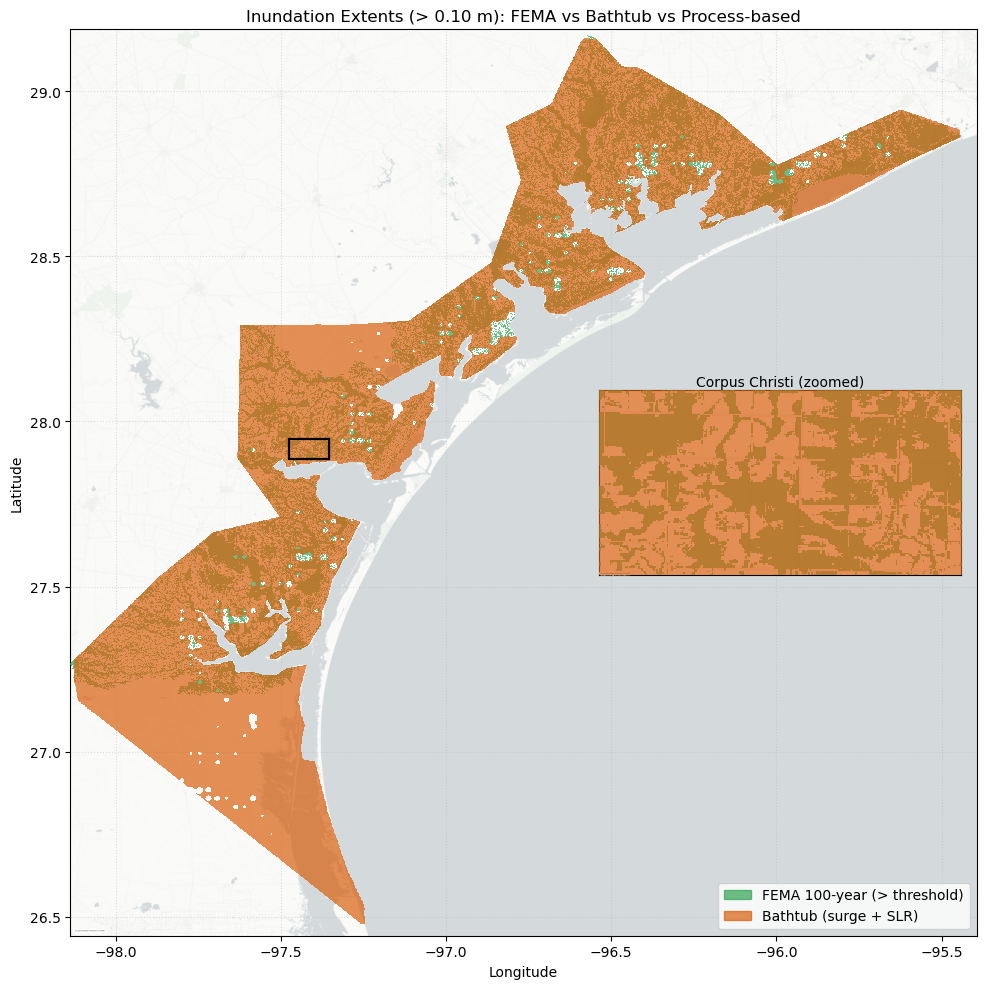

In [12]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import contextily as ctx
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# ---------- USER INPUTS ----------
THRESHOLD = 0.10  # meters; pixel is inundated if depth > THRESHOLD

r_fema     = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Common plotting CRS (lat/lon) and resolution (degrees per pixel)
TARGET_CRS = "EPSG:4326"
TARGET_RES_DEG = 0.0005  # ~45–55 m; increase if memory is an issue

# Inset window (Corpus Christi area) in lon/lat [left, bottom, right, top]
INSET_BBOX = (-97.475853,27.886425,-97.355347,27.947706)   # adjust if needed
INSET_SIZE = ("40%", "40%")                   # inset size relative to the main ax
INSET_LOC  = "center right"                     # where the inset sits on the main fig
INSET_ZOOM = 13                               # basemap zoom for inset
MAIN_ZOOM  = 12                               # basemap zoom for main map
# ----------------------------------

def read_wet_mask(path, threshold=THRESHOLD):
    """Read a depth raster and return (mask_bool, profile_dict). mask_true = depth > threshold."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)
        valid = (~arr.mask) & np.isfinite(arr)
        wet = np.zeros(arr.shape, dtype="uint8")
        wet[valid & (arr > threshold)] = 1
        prof = {
            "crs": src.crs,
            "transform": src.transform,
            "width": src.width,
            "height": src.height
        }
    return wet, prof

def union_bounds_in_target(profiles, target_crs=TARGET_CRS):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        tb = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(tb[0]); ys_min.append(tb[1]); xs_max.append(tb[2]); ys_max.append(tb[3])
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res_deg=TARGET_RES_DEG):
    width  = int(math.ceil((right  - left) / res_deg))
    height = int(math.ceil((top    - bottom) / res_deg))
    transform = from_origin(left, top, res_deg, res_deg)
    return transform, width, height

def reproject_mask_bool(src_mask_uint8, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask_uint8,
        destination=dst,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
    return dst

# --- 1) Read wet masks ---
wet_fema,     prof_fema     = read_wet_mask(r_fema)
wet_bathtub,  prof_bathtub  = read_wet_mask(r_bathtub)
#wet_compound, prof_compound = read_wet_mask(r_compound)

# --- 2) Common grid in EPSG:4326 ---
left, bottom, right, top = union_bounds_in_target(
    [prof_fema, prof_bathtub, prof_compound], target_crs=TARGET_CRS
)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES_DEG)

# --- 3) Reproject masks to common grid ---
dst_fema = reproject_mask_bool(wet_fema, prof_fema, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_bath = reproject_mask_bool(wet_bathtub, prof_bathtub, dst_transform, TARGET_CRS, dst_w, dst_h)
#dst_comp = reproject_mask_bool(wet_compound, prof_compound, dst_transform, TARGET_CRS, dst_w, dst_h)

# --- 4) Colormaps & extent ---
# cmap_compound = ListedColormap([(0, 0, 0, 0), (8/255, 48/255, 107/255, 0.20)])   # dark blue
cmap_bathtub  = ListedColormap([(0, 0, 0, 0), (217/255, 95/255, 14/255, 0.70)])  # orange
cmap_fema     = ListedColormap([(0, 0, 0, 0), (49/255, 163/255, 84/255, 0.70)])  # green
extent = (left, right, bottom, top)

# --- 5) Main plot + basemap ---
fig, ax = plt.subplots(figsize=(11, 10))

# overlays
ax.imshow(dst_fema, extent=extent, origin="upper", cmap=cmap_fema,     interpolation="nearest", zorder=3)
ax.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bathtub,  interpolation="nearest", zorder=4)
#ax.imshow(dst_comp, extent=extent, origin="upper", cmap=cmap_compound, interpolation="nearest", zorder=5)

# basemap underlays
ctx.add_basemap(
    ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=MAIN_ZOOM, zorder=1, attribution_size=0
)

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Inundation Extents (> {THRESHOLD:.2f} m): FEMA vs Bathtub vs Process-based")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)

# legend
legend_patches = [
    mpatches.Patch(color=(49/255, 163/255, 84/255, 0.70), label="FEMA 100-year (> threshold)"),
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.70), label="Bathtub (surge + SLR)"),
    #mpatches.Patch(color=(8/255, 48/255, 107/255, 0.80), label="Process-based compound"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=True)

# --- 6) Inset over Corpus Christi ---
axins = inset_axes(ax, width=INSET_SIZE[0], height=INSET_SIZE[1], loc=INSET_LOC, borderpad=1.1)

# draw the same overlays into the inset (cropped by x/ylim)
axins.imshow(dst_fema, extent=extent, origin="upper", cmap=cmap_fema,     interpolation="nearest", zorder=3)
axins.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bathtub,  interpolation="nearest", zorder=4)
#axins.imshow(dst_comp, extent=extent, origin="upper", cmap=cmap_compound, interpolation="nearest", zorder=5)

# set inset bounds to the Corpus Christi bbox
lx, by, rx, ty = INSET_BBOX
axins.set_xlim(lx, rx)
axins.set_ylim(by, ty)

# inset basemap (higher zoom)
ctx.add_basemap(
    axins, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=INSET_ZOOM, zorder=1, attribution_size=0
)

# tidy inset
axins.set_xticks([]); axins.set_yticks([])
axins.set_title("Corpus Christi (zoomed)", fontsize=10, pad=3)

# draw a rectangle on the main map showing inset coverage
rect = Rectangle((lx, by), rx - lx, ty - by, fill=False, lw=1.6, ec="black", zorder=10)
ax.add_patch(rect)

plt.tight_layout()
plt.show()


C:\Users\sahad2\AppData\Local\Temp\ipykernel_29216\3636897489.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


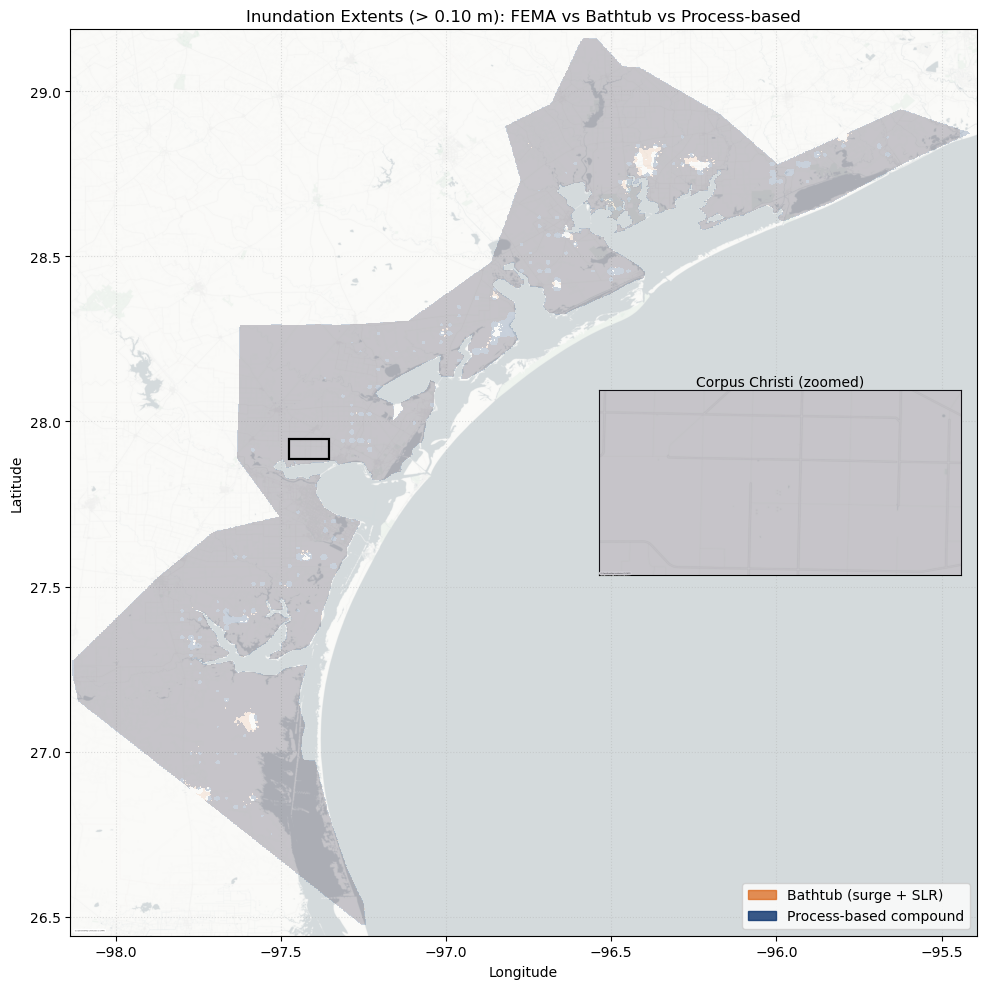

In [13]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import contextily as ctx
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# ---------- USER INPUTS ----------
THRESHOLD = 0.10  # meters; pixel is inundated if depth > THRESHOLD

#r_fema     = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Common plotting CRS (lat/lon) and resolution (degrees per pixel)
TARGET_CRS = "EPSG:4326"
TARGET_RES_DEG = 0.0005  # ~45–55 m; increase if memory is an issue

# Inset window (Corpus Christi area) in lon/lat [left, bottom, right, top]
INSET_BBOX = (-97.475853,27.886425,-97.355347,27.947706)   # adjust if needed
INSET_SIZE = ("40%", "40%")                   # inset size relative to the main ax
INSET_LOC  = "center right"                     # where the inset sits on the main fig
INSET_ZOOM = 13                               # basemap zoom for inset
MAIN_ZOOM  = 12                               # basemap zoom for main map
# ----------------------------------

def read_wet_mask(path, threshold=THRESHOLD):
    """Read a depth raster and return (mask_bool, profile_dict). mask_true = depth > threshold."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)
        valid = (~arr.mask) & np.isfinite(arr)
        wet = np.zeros(arr.shape, dtype="uint8")
        wet[valid & (arr > threshold)] = 1
        prof = {
            "crs": src.crs,
            "transform": src.transform,
            "width": src.width,
            "height": src.height
        }
    return wet, prof

def union_bounds_in_target(profiles, target_crs=TARGET_CRS):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        tb = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(tb[0]); ys_min.append(tb[1]); xs_max.append(tb[2]); ys_max.append(tb[3])
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res_deg=TARGET_RES_DEG):
    width  = int(math.ceil((right  - left) / res_deg))
    height = int(math.ceil((top    - bottom) / res_deg))
    transform = from_origin(left, top, res_deg, res_deg)
    return transform, width, height

def reproject_mask_bool(src_mask_uint8, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask_uint8,
        destination=dst,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
    return dst

# --- 1) Read wet masks ---
#wet_fema,     prof_fema     = read_wet_mask(r_fema)
wet_bathtub,  prof_bathtub  = read_wet_mask(r_bathtub)
wet_compound, prof_compound = read_wet_mask(r_compound)

# --- 2) Common grid in EPSG:4326 ---
left, bottom, right, top = union_bounds_in_target(
    [prof_fema, prof_bathtub, prof_compound], target_crs=TARGET_CRS
)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES_DEG)

# --- 3) Reproject masks to common grid ---
#dst_fema = reproject_mask_bool(wet_fema, prof_fema, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_bath = reproject_mask_bool(wet_bathtub, prof_bathtub, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_comp = reproject_mask_bool(wet_compound, prof_compound, dst_transform, TARGET_CRS, dst_w, dst_h)

# --- 4) Colormaps & extent ---
cmap_compound = ListedColormap([(0, 0, 0, 0), (8/255, 48/255, 107/255, 0.20)])   # dark blue
cmap_bathtub  = ListedColormap([(0, 0, 0, 0), (217/255, 95/255, 14/255, 0.10)])  # orange
#cmap_fema     = ListedColormap([(0, 0, 0, 0), (49/255, 163/255, 84/255, 0.70)])  # green
extent = (left, right, bottom, top)

# --- 5) Main plot + basemap ---
fig, ax = plt.subplots(figsize=(11, 10))

# overlays
#ax.imshow(dst_fema, extent=extent, origin="upper", cmap=cmap_fema,     interpolation="nearest", zorder=3)
ax.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bathtub,  interpolation="nearest", zorder=4)
ax.imshow(dst_comp, extent=extent, origin="upper", cmap=cmap_compound, interpolation="nearest", zorder=5)

# basemap underlays
ctx.add_basemap(
    ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=MAIN_ZOOM, zorder=1, attribution_size=0
)

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Inundation Extents (> {THRESHOLD:.2f} m): FEMA vs Bathtub vs Process-based")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)

# legend
legend_patches = [
    #mpatches.Patch(color=(49/255, 163/255, 84/255, 0.70), label="FEMA 100-year (> threshold)"),
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.70), label="Bathtub (surge + SLR)"),
    mpatches.Patch(color=(8/255, 48/255, 107/255, 0.80), label="Process-based compound"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=True)

# --- 6) Inset over Corpus Christi ---
axins = inset_axes(ax, width=INSET_SIZE[0], height=INSET_SIZE[1], loc=INSET_LOC, borderpad=1.1)

# draw the same overlays into the inset (cropped by x/ylim)
#axins.imshow(dst_fema, extent=extent, origin="upper", cmap=cmap_fema,     interpolation="nearest", zorder=3)
axins.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bathtub,  interpolation="nearest", zorder=4)
axins.imshow(dst_comp, extent=extent, origin="upper", cmap=cmap_compound, interpolation="nearest", zorder=5)

# set inset bounds to the Corpus Christi bbox
lx, by, rx, ty = INSET_BBOX
axins.set_xlim(lx, rx)
axins.set_ylim(by, ty)

# inset basemap (higher zoom)
ctx.add_basemap(
    axins, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=INSET_ZOOM, zorder=1, attribution_size=0
)

# tidy inset
axins.set_xticks([]); axins.set_yticks([])
axins.set_title("Corpus Christi (zoomed)", fontsize=10, pad=3)

# draw a rectangle on the main map showing inset coverage
rect = Rectangle((lx, by), rx - lx, ty - by, fill=False, lw=1.6, ec="black", zorder=10)
ax.add_patch(rect)

plt.tight_layout()
plt.show()


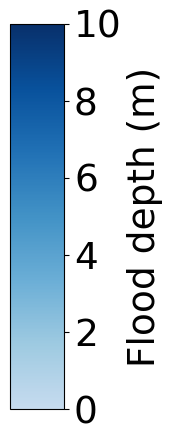

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Continuous range
vmin, vmax = 0, 10  # meters

# Define color transitions (light → dark blue)
colors = [
    (198/255, 219/255, 239/255),  # 0–0.5 very light blue
    (158/255, 202/255, 225/255),
    (107/255, 174/255, 214/255),
    (66/255, 146/255, 198/255),
    (33/255, 113/255, 181/255),
    (8/255, 81/255, 156/255),
    (8/255, 48/255, 107/255)       # ≥10 darkest blue
]

# Build continuous colormap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue", colors, N=256)

# Display the colorbar only
fig, ax = plt.subplots(figsize=(0.7, 5))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                  cax=ax, orientation="vertical")

cb.set_label("Flood depth (m)", fontsize=27)
cb.ax.tick_params(labelsize=27)

plt.show()


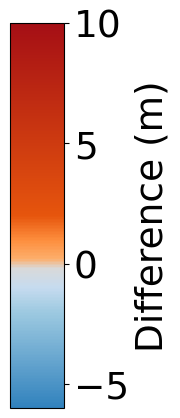

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Continuous value range
vmin, vmax = -6, 10

# Colors taken from your discrete legend in proper order
color_stops = [
    (-6,  "#3182bd"),  # strong blue
    (-2,  "#9ecae1"),  # lighter blue
    (-1,  "#c6dbef"),  # very light blue
    (-0.2,"#d9d9d9"),  # gray
    (0.2, "#fdae6b"),  # light orange
    (1,   "#fd8d3c"),  # orange
    (2,   "#e6550d"),  # dark orange/red
    (10,  "#a50f15")   # deep red
]

# Convert to form usable by LinearSegmentedColormap
positions = [(val - vmin) / (vmax - vmin) for val, col in color_stops]
colors = [col for val, col in color_stops]

# Build continuous custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_diverging", list(zip(positions, colors)))

# Plot the continuous colorbar
fig, ax = plt.subplots(figsize=(0.7, 5))

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation="vertical"
)

cb.set_label("Difference (m)", fontsize=27)
cb.ax.tick_params(labelsize=27)


plt.show()
